Import Libraries

In [1]:
import pandas as pd          # For data handling
import matplotlib.pyplot as plt   # For graphs

Load Dataset

In [3]:
df = pd.read_csv("superstore_cleaned_complete.csv")
df.head()

,category,city,country,customer_id,customer_name,discount,market,column,order_date,order_id,...,sub_category,order_year,order_month,order_quarter,order_day_of_week,is_weekend,order_week,discount_bin,profit_margin,sales_per_unit
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,Us,1,2011-01-07,CA-2011-130813,...,Paper,2011,1,1,4,0,1,0-5%,49.11,6.33
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,Us,1,2011-01-21,CA-2011-148614,...,Paper,2011,1,1,4,0,3,0-5%,48.91,9.50
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,Us,1,2011-08-05,CA-2011-118962,...,Paper,2011,8,3,4,0,31,0-5%,46.87,7.00
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,Us,1,2011-08-05,CA-2011-118962,...,Paper,2011,8,3,4,0,31,0-5%,47.98,55.50
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,Us,1,2011-09-29,CA-2011-146969,...,Paper,2011,9,3,3,0,39,0-5%,51.84,6.00


Understand Data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   category           51290 non-null  object 
 1   city               51290 non-null  object 
 2   country            51290 non-null  object 
 3   customer_id        51290 non-null  object 
 4   customer_name      51290 non-null  object 
 5   discount           51290 non-null  float64
 6   market             51290 non-null  object 
 7   column             51290 non-null  int64  
 8   order_date         51290 non-null  object 
 9   order_id           51290 non-null  object 
 10  order_priority     51290 non-null  object 
 11  product_id         51290 non-null  object 
 12  product_name       51290 non-null  object 
 13  profit             51290 non-null  float64
 14  quantity           51290 non-null  int64  
 15  region             51290 non-null  object 
 16  sales              512

Data Cleaning

In [8]:
df.drop_duplicates(inplace=True)
df.isnull().sum()
df.fillna(0, inplace=True)

Convert Date Column

In [11]:
df['order_date'] = pd.to_datetime(df['order_date'])

Monthly Revenue Trend

In [15]:
df['Month'] = df['order_date'].dt.to_period('M')

In [17]:
monthly_sales = df.groupby('Month')['sales'].sum()

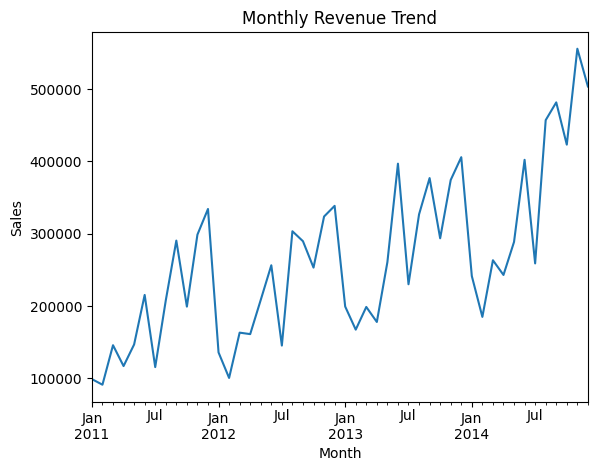

In [18]:
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Top-Selling Products

In [21]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

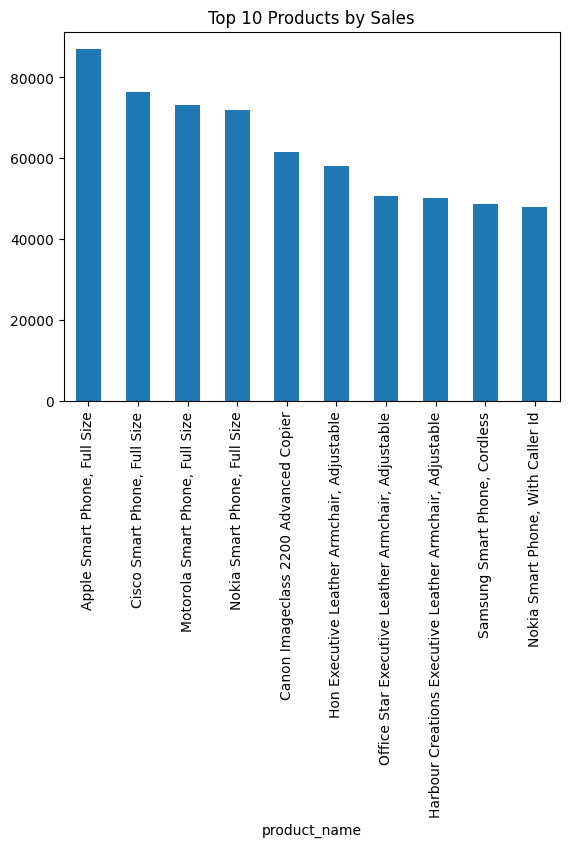

In [22]:
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.show()

Profit Analysis

In [24]:
total_profit = df['profit'].sum()
print(total_profit)

1467457.2912800002


In [28]:
profit_category = df.groupby('category')['profit'].sum()

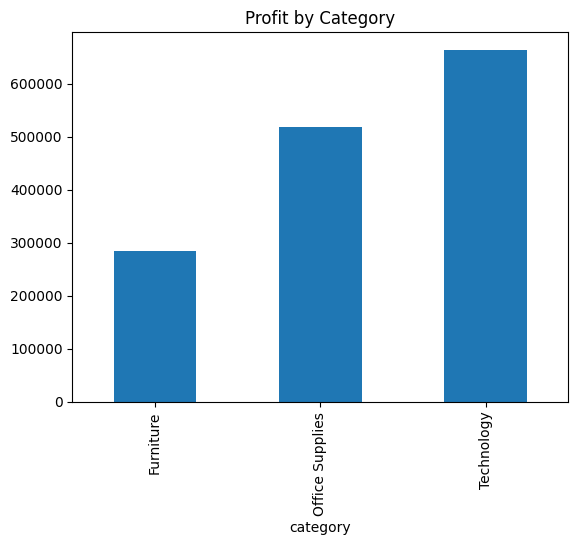

In [29]:
profit_category.plot(kind='bar')
plt.title("Profit by Category")
plt.show()

Sales vs Profit

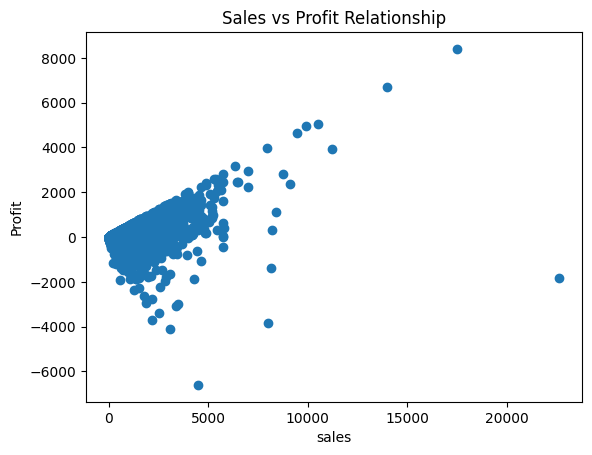

In [32]:
plt.scatter(df['sales'], df['profit'])
plt.xlabel("sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit Relationship")
plt.show()